<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Bank_Fraud_Detection_k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tasks to Perform**
1. Apply at least three clustering techniques presented in this course.




In [1]:
# import required package
import pandas as pd
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import seaborn as sns
from scipy.stats import zscore



#Preporcess the dataset
1. Download the dataset & unzip the dataset
2. Read the dataset using pandas
3. steps:
  * selecting only numerical features
  * creating a derived fraud-related feature (DaysBetweenTransaction)
  * scaling the features
  * find the correct no. of clusters using the Elbow Method
  * applying K-Means
  * visualizing clusters with PCA/t-SNE
  * comparing scaled vs unscaled behavior

In [2]:
# Download the dataset
!kaggle datasets download valakhorasani/bank-transaction-dataset-for-fraud-detection

Dataset URL: https://www.kaggle.com/datasets/valakhorasani/bank-transaction-dataset-for-fraud-detection
License(s): apache-2.0
100% 102k/102k [00:00<00:00, 517kB/s]



In [3]:
# Unzip the dataset
!unzip /content/bank-transaction-dataset-for-fraud-detection.zip

Archive:  /content/bank-transaction-dataset-for-fraud-detection.zip
  inflating: bank_transactions_data_2.csv  


In [4]:
# let's read the dataset csv by pandas
dataset = pd.read_csv('/content/bank_transactions_data_2.csv')
"""
Print the basic dataset infromation
1. How many entries are there in each column
2. How many columns are there
3. The data type  of each coluns
4. Count the null values if exist
5. Memory usage
"""
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [5]:
# Check if there are any columns or rows with empty value
dataset.isnull().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
TransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


As it shows in the dataset information summary there are no columns with null value

In [6]:
# Plot the 5 first head of the dataset
dataset.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [7]:
"""
Get the unique value of channels, customer occupation and Transaction type
these are important information for detecting the transaction
"""
print(f'Channel unique values: {dataset["Channel"].unique()}')
print(f'Customer Ocupation values: {dataset["CustomerOccupation"].unique()}')
print(f'Transaction Type values: {dataset["TransactionType"].unique()}')

Channel unique values: ['ATM' 'Online' 'Branch']
Customer Ocupation values: ['Doctor' 'Student' 'Retired' 'Engineer']
Transaction Type values: ['Debit' 'Credit']


In [8]:
"""
There are 2 diffirent transaction date for each and every transaction
1. TransactionDate: the date of transaction happend
2. PreviousTransactionDate: the previous transaction date
First we have to find out the days/time between two transactions --> this is
very important in order to find out the gap between each transaction
* Also it's important to know how many account is open in a device
"""
# to_datetime make sure the date string is proper converted to standard data time
dataset['TransactionDate'] = pd.to_datetime(dataset['TransactionDate'])
dataset['PreviousTransactionDate'] = pd.to_datetime(dataset['PreviousTransactionDate'])

# make sure the time diffirent is in days format
dataset['DaysBetweenTransaction'] = (dataset['TransactionDate'] - dataset['PreviousTransactionDate']).dt.days

# account per device
dataset['Accounts_per_Device'] = dataset.groupby('DeviceID')['AccountID'].transform('nunique')
# check the DaysBetweenTransaction
dataset.head(5)

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,DaysBetweenTransaction,Accounts_per_Device
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08,-573,6
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35,-496,5
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04,-483,5
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06,-549,6
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39,-385,3


As it shows the Days between transaction added to the dataset

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   TransactionID            2512 non-null   object        
 1   AccountID                2512 non-null   object        
 2   TransactionAmount        2512 non-null   float64       
 3   TransactionDate          2512 non-null   datetime64[ns]
 4   TransactionType          2512 non-null   object        
 5   Location                 2512 non-null   object        
 6   DeviceID                 2512 non-null   object        
 7   IP Address               2512 non-null   object        
 8   MerchantID               2512 non-null   object        
 9   Channel                  2512 non-null   object        
 10  CustomerAge              2512 non-null   int64         
 11  CustomerOccupation       2512 non-null   object        
 12  TransactionDuration      2512 non-

In [10]:
# Define number of clustering
print(f"The dataset has shape = {dataset.shape}")
print(f"It has {dataset.shape[0]} objects and {dataset.shape[1]} attributes.\n")

# Define a palette of colours for the K clusters
PAL = ['black', 'red', 'green', 'blue', 'yellow', 'orange']

"""
I am only interested in nomerical features
"""
features = dataset[[
    "TransactionAmount",
    "CustomerAge",
    "TransactionDuration",
    "LoginAttempts",
    "AccountBalance",
    "DaysBetweenTransaction",
    "Accounts_per_Device"
]]
[N,M] = features.shape # N=Number of object, M=Number of attribute
print(f"The features has shape = {features.shape}")
print(f"It has {N} objects and {M} attributes.")


The dataset has shape = (2512, 18)
It has 2512 objects and 18 attributes.

The features has shape = (2512, 7)
It has 2512 objects and 7 attributes.


In [11]:
"""
Get the statistical summary of nomerical columns(features)
This summary includes key statistical metrics like
[mean, standard deviation, minimum, maximum, different percentiles]
"""
features.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,DaysBetweenTransaction,Accounts_per_Device
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966,-487.857882,4.541401
std,291.946243,17.792198,69.963757,0.602662,3900.942499,106.378910,1.820685
min,0.260000,18.000000,10.000000,1.000000,101.250000,-672.000000,1.000000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000,-581.000000,3.000000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000,-486.000000,4.000000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000,-395.000000,6.000000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000,-308.000000,9.000000


In [ ]:
"""
Let's quickly summarize numerical and categorical data using summarytools
First we have to install it
"""
!pip install summarytools

In [13]:
from summarytools import dfSummary

dfSummary(features)

No,Variable,Stats / Values,Freqs / (% of Valid),Graph,Missing
1,TransactionAmount[float64],Mean (sd) : 297.6 (291.9)min < med < max:0.3 < 211.1 < 1919.1IQR (CV) : 332.6 (1.0),"2,455 distinct values","<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAmRJREFUeJzt3DFv2kAYh/H3CkEGWgMigs0rWwdGln6DftiuHSPBzLdASFYA4YaAkLuUqlLSAHeh9f/0/GZ8ZnhkdMj3urIsDai6D//7CwCXqJ/7gHOuaWYNz/X3ZVk+eV4L/PZmqM65Zr/f/5qmac9n8c1m8+ic+0asCHXuidpI07Q3mUyeOp3O7pqF1+t1Mp1Oe3meN8yMUBHk7E+/mVmn09kNBoMfHus3Pa4BXmAzBQmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgmECgkXzZ7ydTwe78wsdc75LsHYSpjZDUMtiuLucDh8zrKsVqvVrpoEeMLYSpzcLNT9fl9PkqQ1Ho93w+Hw8drrGVuJP930p9/MrN1u+46sNGNsJX5hMwUJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJhAoJN3/NL0TgCQFOB0SksqGGnhDgdEBcKhtqyAkBTgfEp7KhngScEOB0QETYTEECoUICoUICoUJC5TdTvpjSEpcoQ2VKS3yiDJUpLfGJMtQTprTEg80UJET9RA3BCzHVQqiv4IWY6iHUV4S+EPPw8DDI8/zeObfxuT2Bv0Sob/DZjIU+jVer1dY5993MvP5Ws0hDJ9R3FvI0XiwWn2az2Zcsy+59//8NDL2ykV8U6nq9Tq5deLvdJmZmRVEky+Wy9S+vr8K9fRwOh3qSJK3RaOS63e7ztdevVquP8/ncO/R3eJqHeC7L8q/3/QnyizBFO1kSwgAAAABJRU5ErkJggg=="">",0(0.0%)
2,CustomerAge[int64],Mean (sd) : 44.7 (17.8)min < med < max:18.0 < 45.0 < 80.0IQR (CV) : 32.0 (2.5),63 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAqxJREFUeJzt3UFu2kAUgOE3JSADqhEigh0XqNQFSza9QQ/bbXdFChfgBmwQkmVAuLEAQzdJ1LRQ8IydznP+bx2MF78g4zcjzOl0EsB3H/73DQC3uLv2B8aYpog0LK+/O51Oj5avBV78M1RjTLPX630Nw7Brc/HVarU1xnwXkdTq7ggdT659ojbCMOyOx+PHTqeTK7bFYvFxOp1+GQ6H97VazSrUzWYTG2O+ESuufvWLiHQ6nbTf7//Mc+E4jptBELRGo1E6GAzivDe2Xq+Dh4eHbhRFDREh1HfuplBdtNvt3JH/plnozUAtVv1QgVChAqFCBUKFCoQKFQgVKhAqVCj9Oep7xP6I4hFqwVz3RzA2Po9Qi2e9P4Kx8WWEWhKb/RFPGBufwWIKKhAqVCBUqMD/qJ7JsqwuIqExxvYSlXy8RageSZKkvt/vPw+HwxqnIl4jVI/sdrs7TkWcR6ge4lTE31hMQQVChQqEChUIFSoQKlQgVKjA46mKcZxseTvVItQKcZ1s+TzVItQKcZls+T7VItQKcphseTvVYjEFFbz+RK3qwgD5eRtqlRcGyM/bUF0XBpPJpB9F0b0xZmN7C0TuD29DfWazMChiA7LD7w+Ex+OxbvOeuMz7UG24bkB2+f2B/X4fZFn2KU3THyJiu6cUf6hkqM9sH9O4/P7AfD7vzmaz1uFwqOV9X1xW6VBd2YQex7G3zyI1I1S88PkELKFCRPw/AUuoEBH/T8ASKl5xOQGbZVkoJU0SCRWFKHuSSKgoRNlbDAkVhSpriyHb/KACoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgVChQo3nZlar9dB3gtvt9tARCRJkmC5XLbe8vVa31vrfbu+/pa+fgEUB7fVRC80+gAAAABJRU5ErkJggg=="">",0(0.0%)
3,TransactionDuration[int64],Mean (sd) : 119.6 (70.0)min < med < max:10.0 < 112.5 < 300.0IQR (CV) : 98.0 (1.7),288 distinct values,"<img src = ""data:image/png;base64, iVBORw0KGgoAAAANSUhEUgAAAKoAAABGCAYAAABc8A97AAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAsIGh0dHBzOi8vbWF0cGxvdGxpYi5vcmcvlHJYcgAAAAlwSFlzAAAPYQAAD2EBqD+naQAAAuNJREFUeJzt3T1v2kAYwPHnIETHi2zxUtiydIzUASlLPkDHfth+hCAxdGbo0oktEkKguEEYmw4NUgeS4Ltz8RP+v/2Chz8+c470mP1+L0DV1c59AcAprs59AVVljGmKyLXj8u1+v38OeT2XjlCPMMY0+/3+tyiKui7r1+v10hjznVjDIdTjrqMo6t7f3z/HcbwpsnC1WtnpdNpdLBbXIkKogZQaquf2KXLmLTSO481wOPztsLQZ/GIuXGmh+m6fIn5bqOeXJMrzvOG4FiUo847qvH2K/N1CJ5PJcLFYDIwx64LLba/X+xrHcbvo54qIpGlqsyy73Ww2DyLickdFYKU/o7pun0mSNNI0/XJzc1Ov1+uFQk/T1IrI7d3d3Y/BYFA0cpnP593ZbNba7Xb1omtRjsr+mNput1fW2tZ4PN6MRqNlkbWH0Ky1qcuXZLlc8oxZMZUN9aDdbhe+IxPax1P5UDXKsqwhIpExxmU5LwuOINTAfJ6tRXhZ8BpCDczn2ZqXBa97N1SP88iLPot0ebZ+wfP1EW+G6nNoz1kkQnrvjup8aM9ZJEI66RnV5dCeIyKExD9OQwVChQqEChUIFSoQKlQgVKhAqFCBUKECoUIFQoUKhAoVCBUqECpUIFSoQKhQgVChAqFCBUKFCoQKFQgVKhAqVCBUqECoUIFQoQKhQgVChQqEChUIFSoQKlQgVKhAqFCBUKECwyYQjOf82TfHFhEqgvAd0vze2CJCRSjO8x5OGVtEqB+M5/ZbE5HccW2U53kjjuNlGWOLCLViPMdTOo9/z7KskSTJ506n86tWq6VF15c9rolQK8R3PKXP+PeXcUufxuPxz6ITB/9ZX9q4JkKtEJ/xlCJ+498P45ZcJw6WPa6JUCuoqrGcEwf+UIFQoQKhQgVChQqEChUIFSoQKlQgVKhAqFCBUKECoUKFk971r1YrW/QPPz09WRGRJEns4+Nj63+u1/rZWq/bd/0pff0B8/CAdm0ZvV0AAAAASUVORK5CYII="">",0(0.0%)
4,LoginAttempts[int64],1. 12. 53. 44. 35. 2,"2,390 (95.1%)32 (1.3%)32 (1.3%)31 (1.2%)27 (

## Explore the data


In [14]:
def plot_data_distribution(x, short_title, box=True):
  """
  x: the column name like "TransactionAmount"
  short_title: a short name of columns
  """
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  sns.histplot(data=features, x=x, bins=20, kde=True, ax=axes[0])
  axes[0].set_title(f'{short_title} Distribution')
  axes[0].set_xlabel(f'{short_title}')
  axes[0].set_ylabel('Frequency')
  if box is not False:
    sns.boxplot(data=features, x=x, ax=axes[1])
    axes[1].set_title(f'Box Plot of {short_title}')
    axes[1].set_xlabel(f'{short_title}')

  plt.tight_layout()
  plt.show()

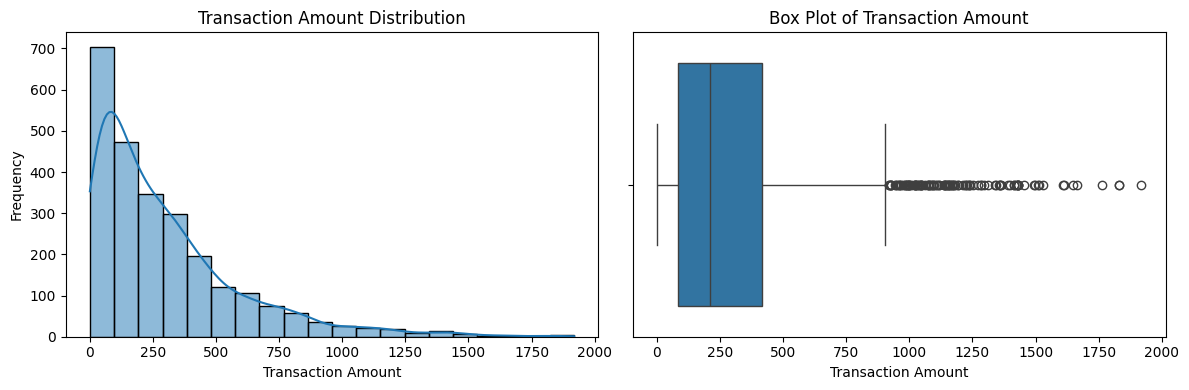

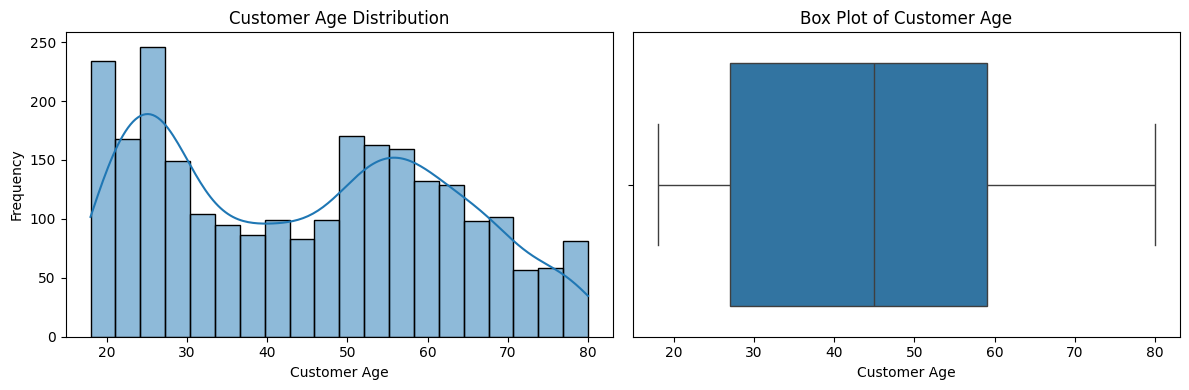

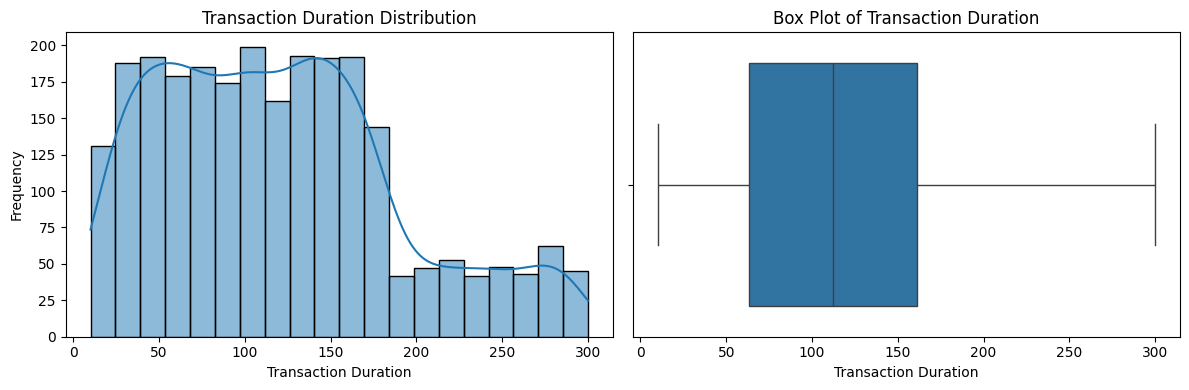

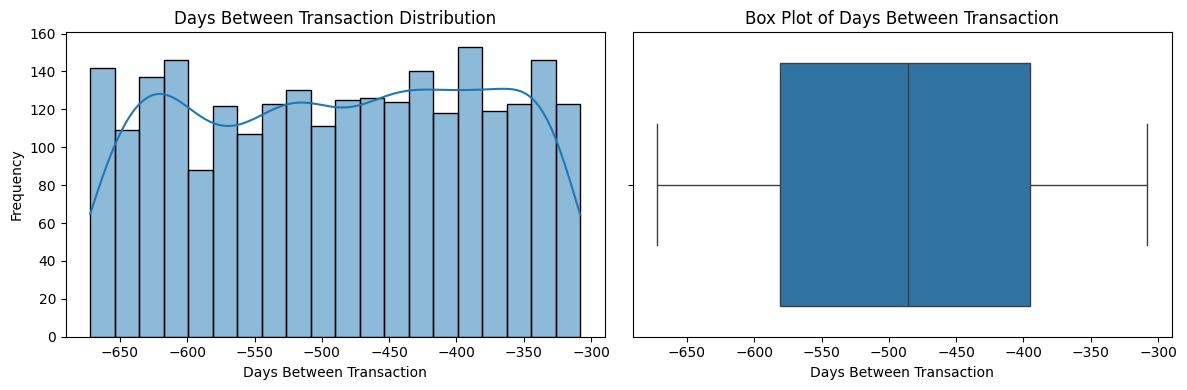

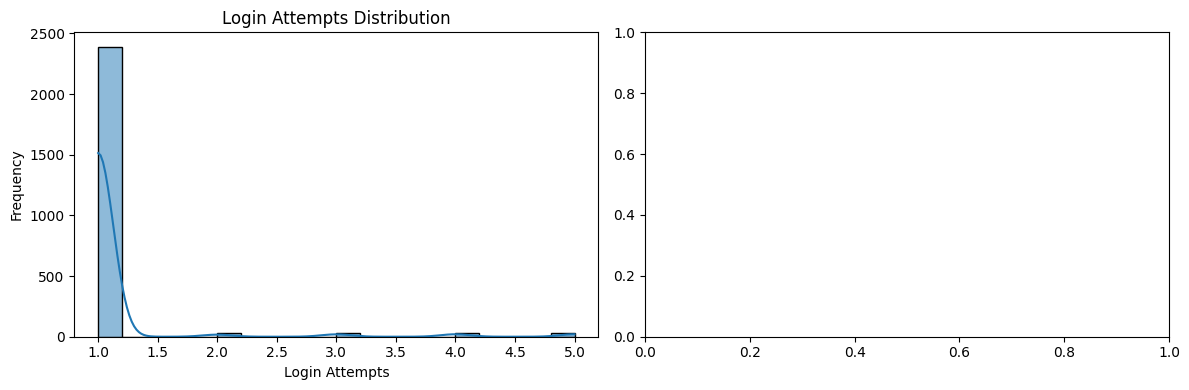

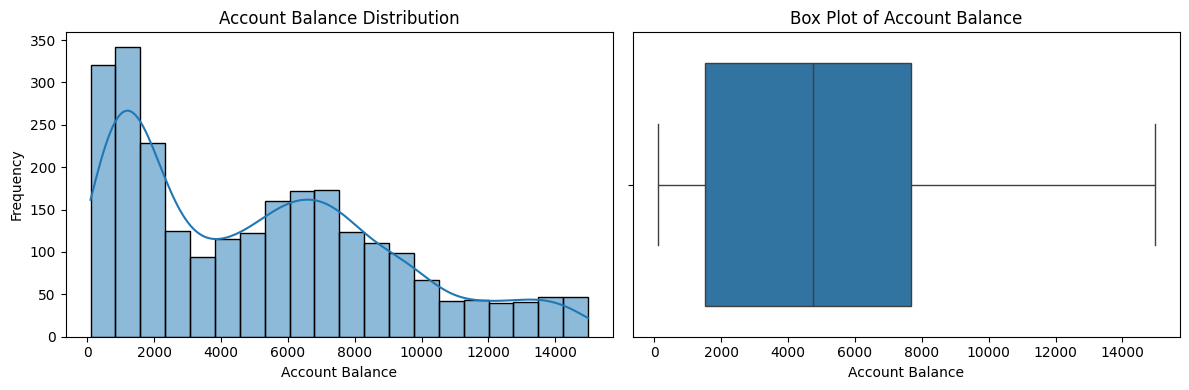

In [15]:
"""
Let's check the data distribution of some feature
"""
plot_data_distribution('TransactionAmount', "Transaction Amount")
plot_data_distribution('CustomerAge', "Customer Age")
plot_data_distribution('TransactionDuration', "Transaction Duration")
plot_data_distribution('DaysBetweenTransaction', "Days Between Transaction")
plot_data_distribution('LoginAttempts', "Login Attempts", box=False)
plot_data_distribution('AccountBalance', "Account Balance")

Ass it shows in the distribution plots we have some outliers

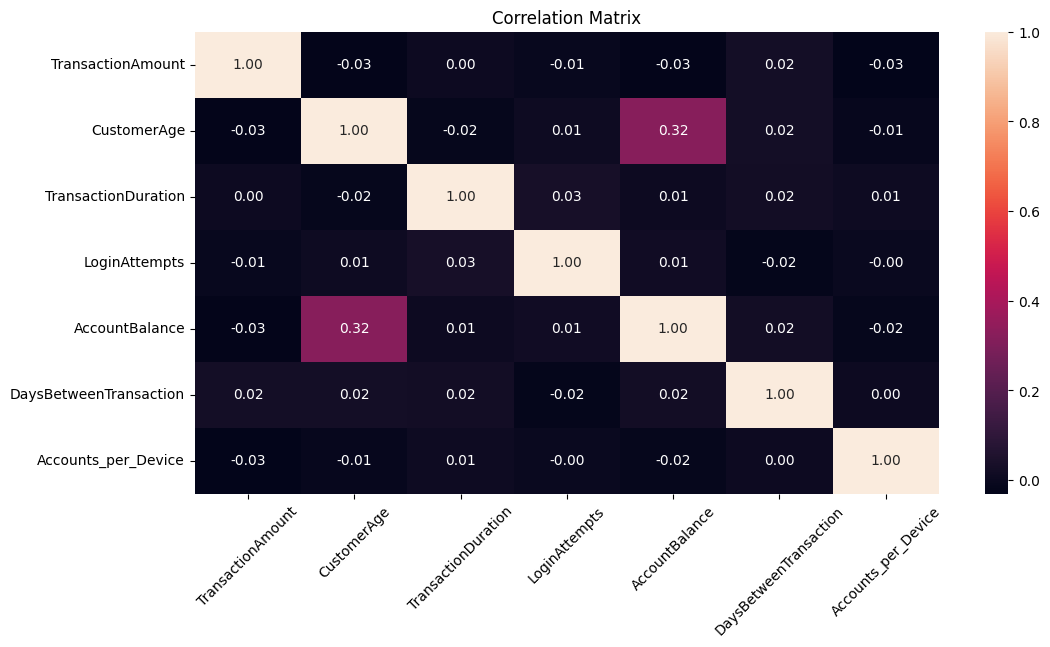

In [16]:
numerical_columns = features.columns

corr = features[numerical_columns].corr()
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.xticks(rotation=45)
plt.title('Correlation Matrix')
plt.show()

This correlation matrix visualizes the relationships and behavior of variables, with values ranging from -1 to 1.

* Strongest Positive Correlation: The strongest relationship is between CustomerAge and AccountBalance, with a correlation coefficient of 0.32, indicating as a customer gets older, their account balance generally goes up.
* Weak Correlations: Most other variables show very weak or no linear relationship, with coefficients close to 0.00.
* This helps identify how variables relate to one another to determine which features might be useful.



/tmp/ipykernel_2382/1758553653.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


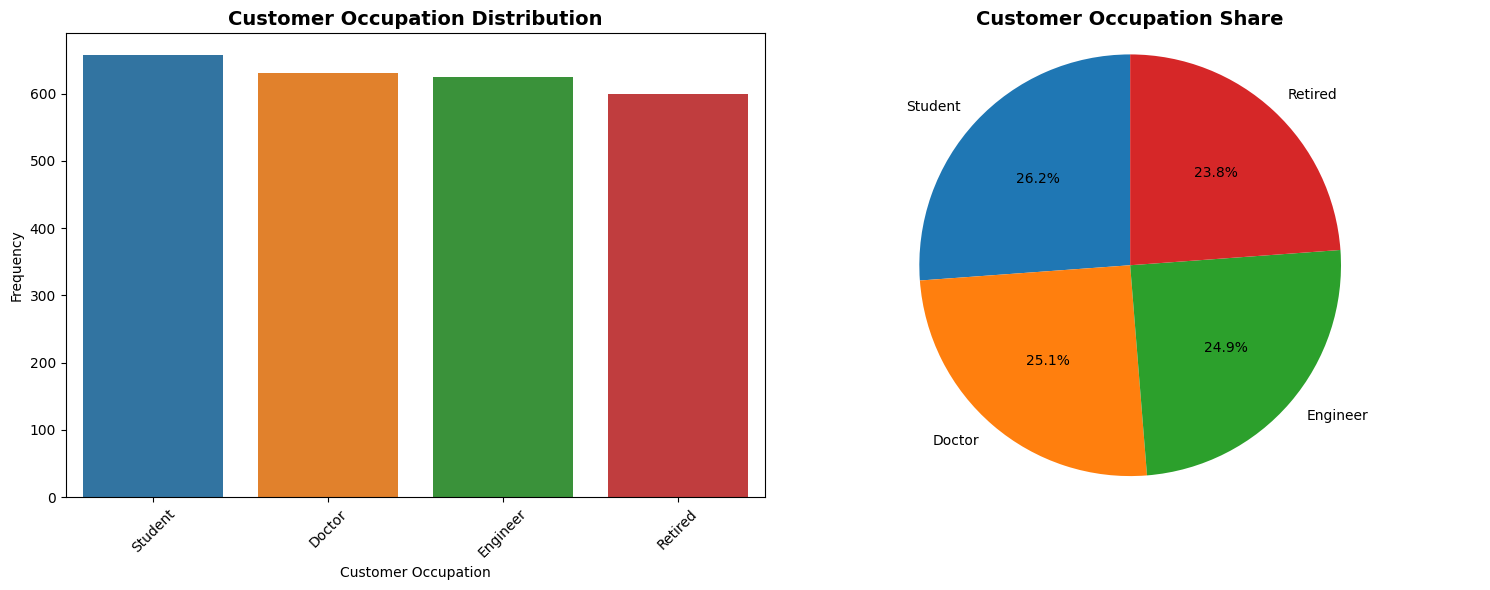

In [17]:
"""
We are not going to use customer occupation for the clustering but it's important
to undrestand the distribution
"""
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

occupation_counts = dataset['CustomerOccupation'].value_counts()
order = occupation_counts.index

sns.countplot(
    data=dataset,
    x='CustomerOccupation',
    order=order,
    palette="tab10",
    ax=axes[0]
)

axes[0].set_title('Customer Occupation Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Customer Occupation')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(
    occupation_counts,
    labels=order,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("tab10", len(order))
)

axes[1].set_title('Customer Occupation Share', fontsize=14, fontweight='bold')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2382/2953334294.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=dataset, x='Accounts_per_Device', palette=palette)
/tmp/ipykernel_2382/2953334294.py:5: UserWarning: The palette list has more values (20) than needed (9), which may not be intended.
  ax = sns.countplot(data=dataset, x='Accounts_per_Device', palette=palette)


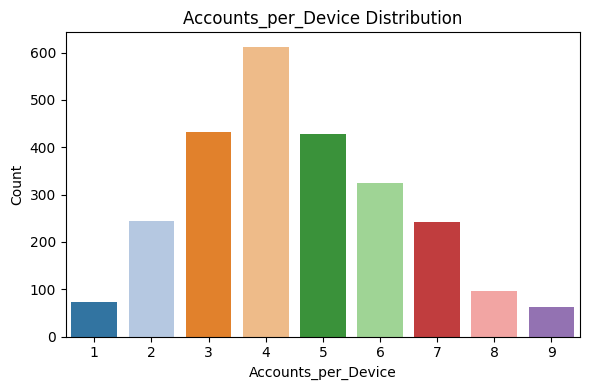

In [18]:
plt.figure(figsize=(6, 4))

palette = sns.color_palette("tab20")

ax = sns.countplot(data=dataset, x='Accounts_per_Device', palette=palette)

plt.title('Accounts_per_Device Distribution')
plt.xlabel('Accounts_per_Device')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

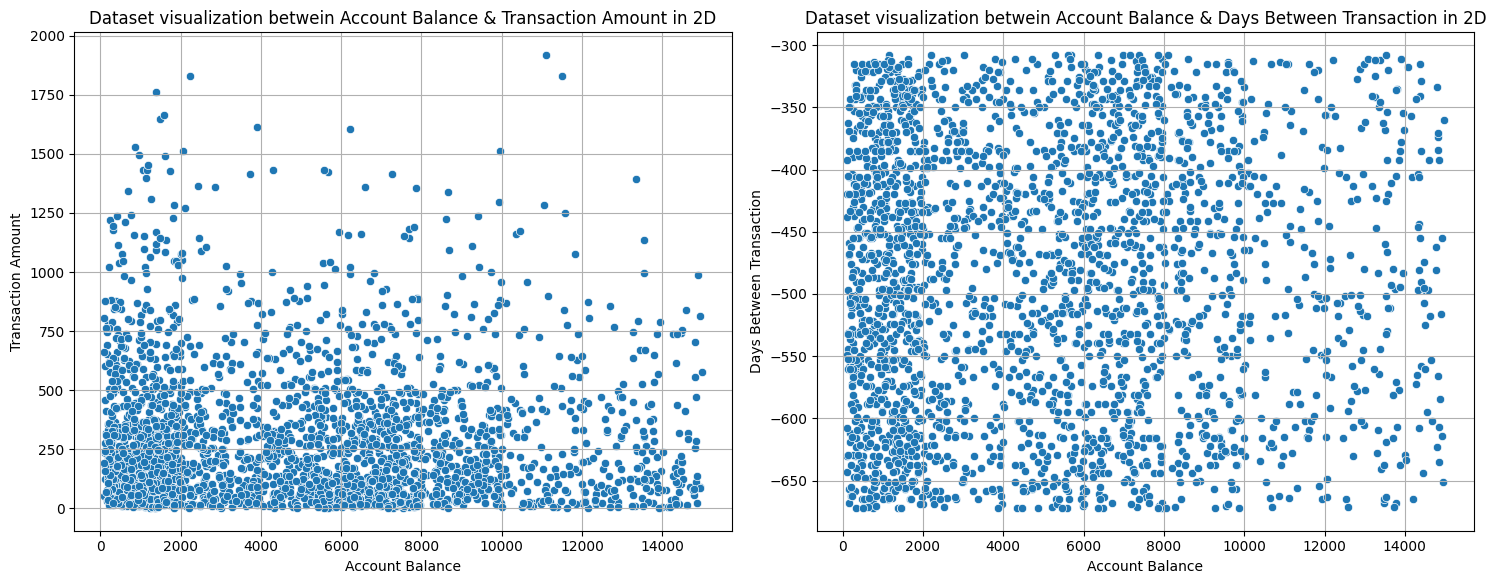

In [19]:
"""
Visualize the Account Balance vs Transaction Amount
and AccountBalance vs DaysBetweenTransaction
"""

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Account Balance vs Transaction Amount
sns.scatterplot( x = features['AccountBalance'], y = features['TransactionAmount'], ax=ax[0])
sns.set_theme(style='dark')
ax[0].set_title('Dataset visualization betwein Account Balance & Transaction Amount in 2D')
ax[0].set_xlabel(f'Account Balance')
ax[0].set_ylabel(f'Transaction Amount')
ax[0].grid()

# Account Balance vs Days Between Transaction
sns.scatterplot( x = features['AccountBalance'], y = features['DaysBetweenTransaction'], ax=ax[1])
sns.set_theme(style='dark')
ax[1].set_title('Dataset visualization betwein Account Balance & Days Between Transaction in 2D')
ax[1].set_xlabel(f'Account Balance')
ax[1].set_ylabel(f'Days Between Transaction')
ax[1].grid()
plt.tight_layout()


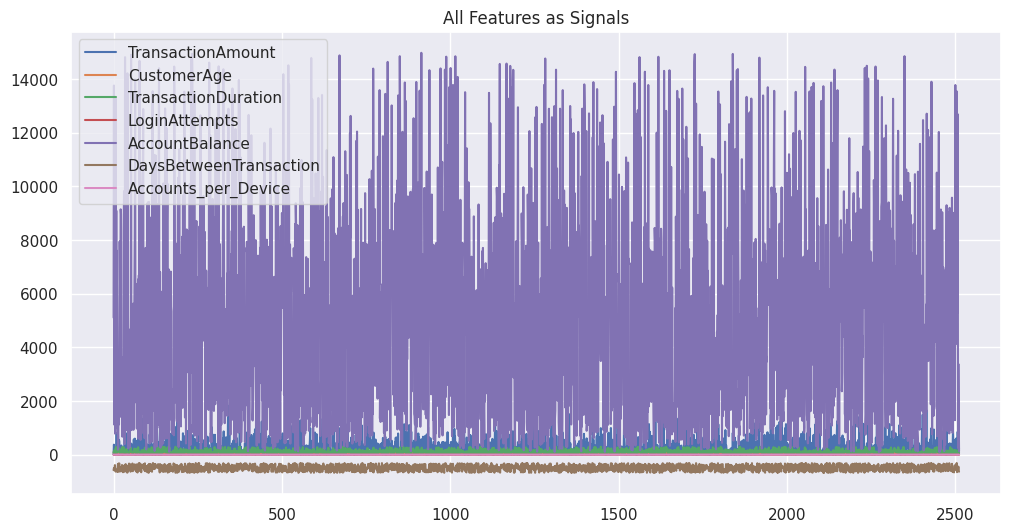

In [20]:
plt.figure(figsize=(12,6))

for col in features.columns:
    plt.plot(features[col], label=col)

plt.legend()
plt.title("All Features as Signals")
plt.grid(True)
plt.show()

In [21]:
"""
Let's visualize the PCA & tSNE
"""
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

def PCA_tSNE_visualization(data_2d, n_components, labels, PAL, CENTROIDS=None, SSE=None):
  """
  INPUT
  data_2d --> a 2D data matrix to visualize
  n_components ---> no. of components to decompose the dataset during PCA
  labels ---> labels given by the clustering
  PAL ---> palette of colours to distinguish between clusters
  """

  '''
  OUTPUT
  Two figures ---> one using PCA and one using tSNE
  '''


  # get the PCA
  pca = PCA(n_components=n_components)
  pca_result = pca.fit_transform(data_2d)
  print('PCA explained variance: ', pca.explained_variance_ratio_.round(2))

  # transform centroids INTO PCA SPACE
  if CENTROIDS is not None:
      centroids_pca = pca.transform(CENTROIDS)

  # get the tSNE
  tsne = TSNE(n_components=n_components, verbose=0, perplexity=20, max_iter=300)
  tsne_results = tsne.fit_transform(data_2d)

  # Plots
  fig, ax = plt.subplots(1, 2, figsize=(15, 6))
  fig.suptitle(f'SSE {SSE}')


  # Plot 1: PCA features
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)

  ax[0].set_xlabel('Dimension 1', fontsize=10)
  ax[0].set_ylabel('Dimension 2', fontsize=10)

  # plot centroids if provided
  if CENTROIDS is not None:
    for i in range(centroids_pca.shape[0]):
      ax[0].scatter(
          centroids_pca[i, 0],
          centroids_pca[i, 1],
          s=250,
          color=PAL[i],
          marker='X',
          edgecolor='black',
          label=f'Centroid {i}'
      )

  ax[0].set_title("PCA")
  ax[0].legend()
  ax[0].grid()

  # Plot 1: TSNE features
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)
  ax[1].set_xlabel('Dimension 1', fontsize=10)
  ax[1].set_ylabel('Dimension 2', fontsize=10)
  ax[1].title.set_text('tSNE')
  ax[1].grid()
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

To choose the best K for K-Means Clustering, I will be using Elbow Method.

The idea:

* Try many values of K
* Compute the SSE (inertia) for each K
* Plot the curve
* Choose the point where the decrease starts slowing down

SSE 1: 17584.000000000015
SSE 2: 15145.330370473504
SSE 3: 12984.04283012255
SSE 4: 11833.103502096003
SSE 5: 10618.608969051591
SSE 6: 9832.106583312216
SSE 7: 9139.967112236747
SSE 8: 8668.481959364013
SSE 9: 8210.168598665952
SSE 10: 7889.021207588868


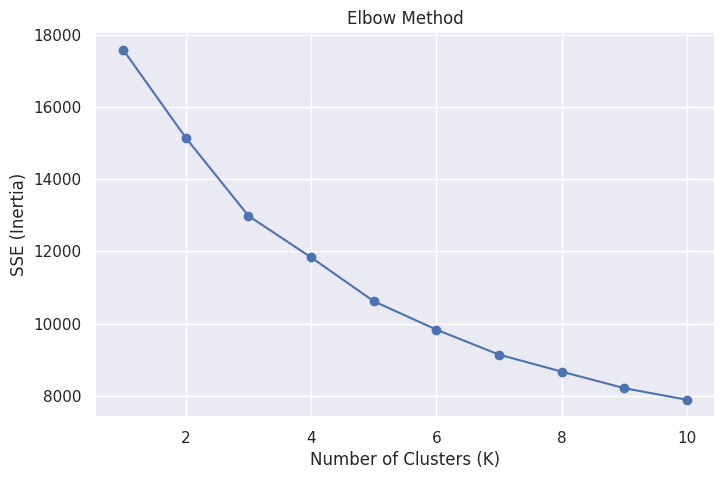

In [22]:
scaler = StandardScaler()
X = scaler.fit_transform(features)
SSE = []

K_values = range(1, 11)
for k in K_values:
    kmeans = KMeans(
        n_clusters=k,
        n_init=10,
        random_state=42
    )
    kmeans.fit(X)
    print(f'SSE {k}: {kmeans.inertia_}')
    SSE.append(kmeans.inertia_)
plt.figure(figsize=(8,5))

plt.plot(K_values, SSE, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

**As it shows in the Elbow Method the SSE slow down at K=3**

In [23]:
K=3
N_INIT=10

In [24]:
"""
Let's calculate the k-menas of the features
"""
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=K, init='random', n_init=N_INIT, max_iter=300, tol=0.0001, verbose=0, random_state=42).fit(features)

# Print the final minimized Sume of Squared Error(SSE)
print(f'\nThe final SSE is: {kmeans.inertia_} ')

# get the k-means labels
features_lables = kmeans.labels_
# get the centroid for each clusters
centroids = kmeans.cluster_centers_


The final SSE is: 4516721357.711052 


PCA explained variance:  [0.99 0.01]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/tmp/ipykernel_2382/1725313027.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_2382/1725313027.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


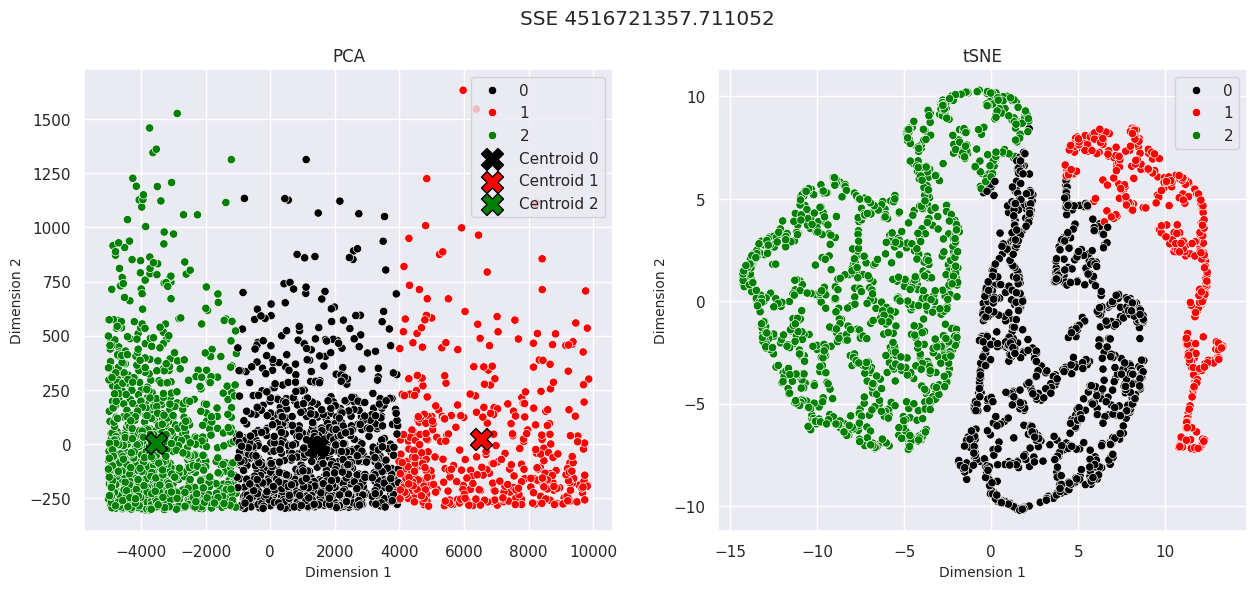

In [25]:
"""
Plot the PCA and tSNE of features without scalling
"""
DIMENSIONS = 2
PCA_tSNE_visualization(features, DIMENSIONS, features_lables, PAL, centroids, kmeans.inertia_)


Meaning:
* The principal component explains 99% of the variance
* Second explains 1%

So the data is almost lying along ONE dominant direction.

This usually happens because:

* *one feature dominates the dataset*
* features are highly correlated
* scaling was not applied correctly

**In order to overcome the *feature dominants* it's better to scale individual variable based on their distribution (column by column)**

In [26]:
from sklearn.preprocessing import StandardScaler

"""
Scale all important nomerical columns
"""
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [27]:
"""
Let's calculate the k-menas of the scaled features
"""

scaled_kmeans = KMeans(n_clusters=K, init='random', n_init=N_INIT, max_iter=300, tol=0.0001, verbose=0, random_state=42).fit(scaled_features)

# Print the final minimized Sume of Squared Error(SSE)
print(f'\nThe final SSE without scaled is: {kmeans.inertia_} ')
print(f'The final SSE with scaled is: {scaled_kmeans.inertia_} ')

# get the k-means labels
scaled_features_lables = scaled_kmeans.labels_
# get the centroid for each clusters
scaled_centroids = scaled_kmeans.cluster_centers_
print(f'Labels after scaled: {np.unique(scaled_features_lables)}')


The final SSE without scaled is: 4516721357.711052 
The final SSE with scaled is: 13823.037428573994 
Labels after scaled: [0 1 2]


As it shows the Final **SSE** for after scaled is also reduce a lot

Which measures:
* How far points are from their cluster centroids
* Lower SSE means better compact clusters

PCA explained variance:  [0.19 0.15]


/tmp/ipykernel_2382/1725313027.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_2382/1725313027.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


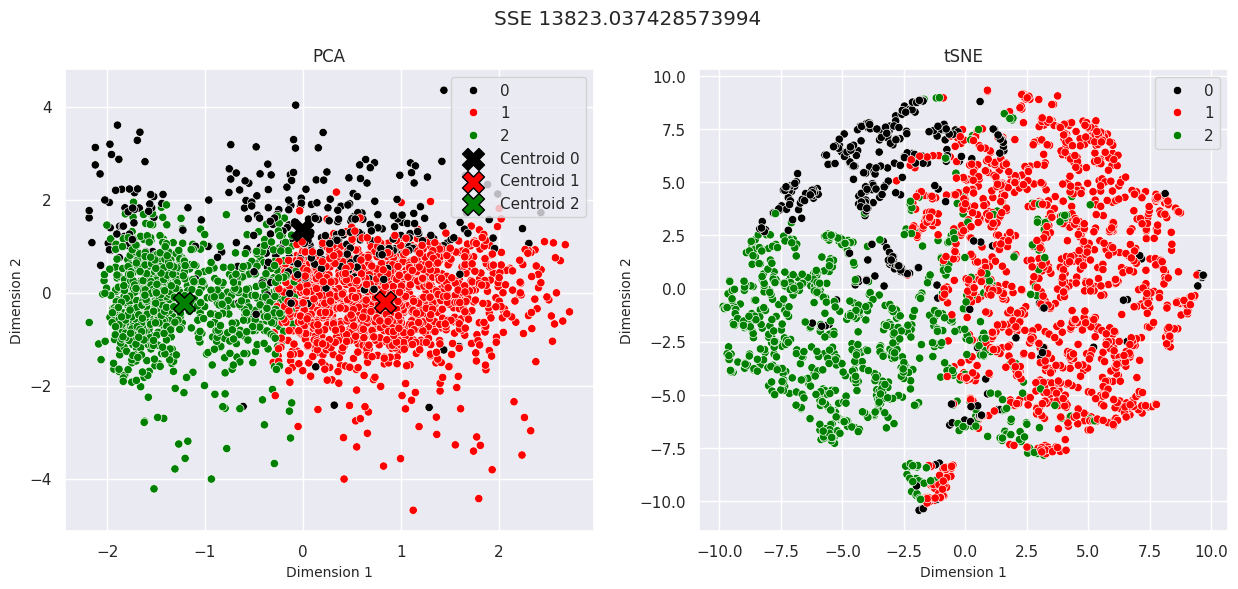

In [28]:
"""
Plot the PCA and tSNE of scaled features
"""
PCA_tSNE_visualization(scaled_features, DIMENSIONS, scaled_features_lables, PAL, scaled_centroids, scaled_kmeans.inertia_)

Now I have:

* PC1 explains 22% of variance
* PC2 explains 17% of variance

Which means my data
* is **NOT dominated** by one feature anymore
* is more **balanced** across features
* has more **complex structure**

In [29]:
"""
Let's calculate the k-menas++ of the scaled features
"""

kmeansPLUS = KMeans(n_clusters=K, init='k-means++', n_init=N_INIT, max_iter=300, tol=0.0001, verbose=0, random_state=42).fit(scaled_features)

# Print the final minimized Sume of Squared Error(SSE)
print(f'\nThe final SSE without scaled is: {kmeans.inertia_} ')
print(f'The final SSE with scaled is: {scaled_kmeans.inertia_} ')
print(f'The final SSE with scaled is using k-means++: {kmeansPLUS.inertia_} ')

# get the k-means labels
kmeansPLUS_features_lables = kmeansPLUS.labels_
# get the centroid for each clusters
scaled_kmeansPLUS_centroids = kmeansPLUS.cluster_centers_
print(f'Labels after scaled using k-means++: {np.unique(kmeansPLUS_features_lables)}')


The final SSE without scaled is: 4516721357.711052 
The final SSE with scaled is: 13823.037428573994 
The final SSE with scaled is using k-means++: 12984.04283012255 
Labels after scaled using k-means++: [0 1 2]


PCA explained variance:  [0.19 0.15]


/tmp/ipykernel_2382/1725313027.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_2382/1725313027.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


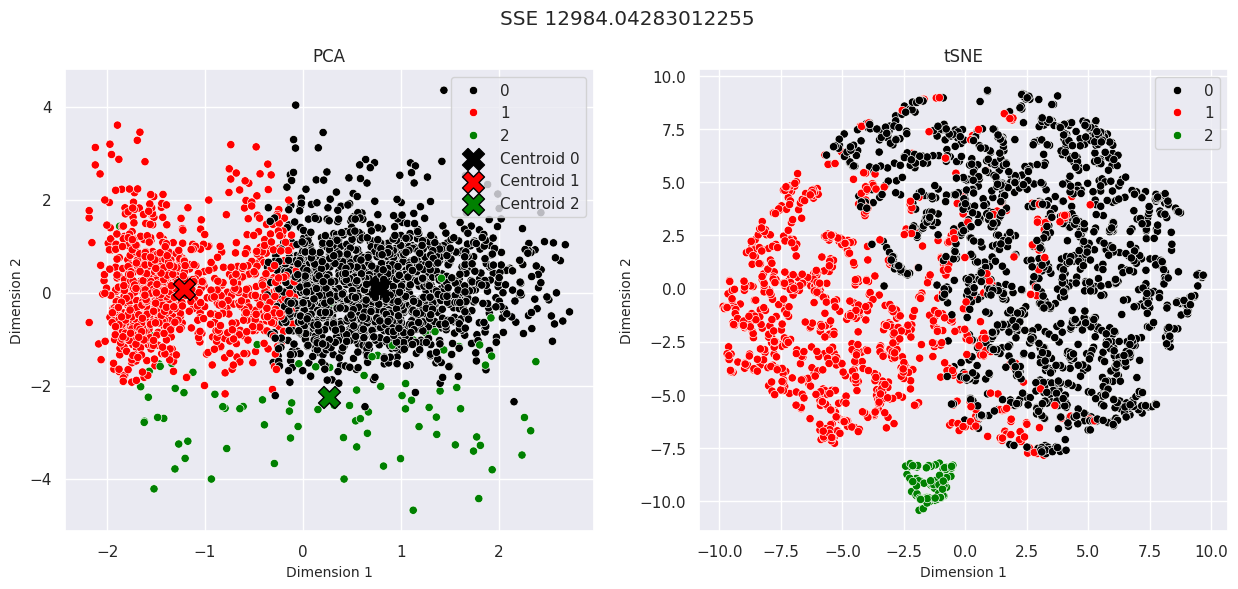

In [30]:
"""
Plot the PCA and tSNE of scaled features for k-means++
"""
PCA_tSNE_visualization(scaled_features, DIMENSIONS, kmeansPLUS_features_lables, PAL, scaled_kmeansPLUS_centroids, kmeansPLUS.inertia_)

# Final Clusters with K-means++

**From the visualization and process it's I undrestand the best best number of cluster `K=3` and the number of iteration `n-iter=10` and the best method of k-means aproach is `k-means++`**

Now let's **remove the outliers** to retrive the final version of the k-means clustering

In [31]:
"""
Find the outliers with the threshold of 3
"""
threshold = 3
z_scores = np.abs(zscore(features))

outliers = (z_scores > threshold)

print(f'Total number of outliers: {outliers.sum()}')

Total number of outliers: 143


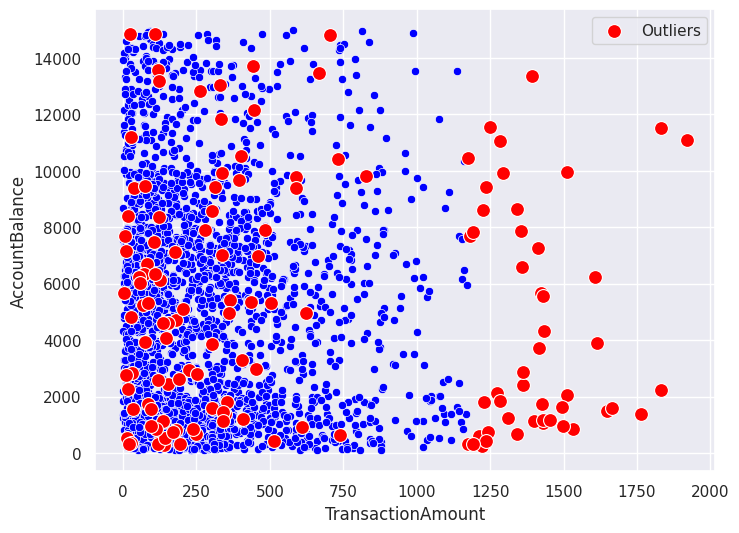

In [32]:
"""
Plot the outliers for Transaction amount and Account Balance in a 2D
Since we can not visualize more than 2D will just plot this
"""
z_scores = np.abs(zscore(features))

outlier_rows = (z_scores > threshold).any(axis=1)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=features["TransactionAmount"],
    y=features["AccountBalance"],
    color='blue'
)

sns.scatterplot(
    x=features[outlier_rows]["TransactionAmount"],
    y=features[outlier_rows]["AccountBalance"],
    color='red',
    s=100,
    label='Outliers'
)

plt.legend()
plt.grid(True)
plt.show()

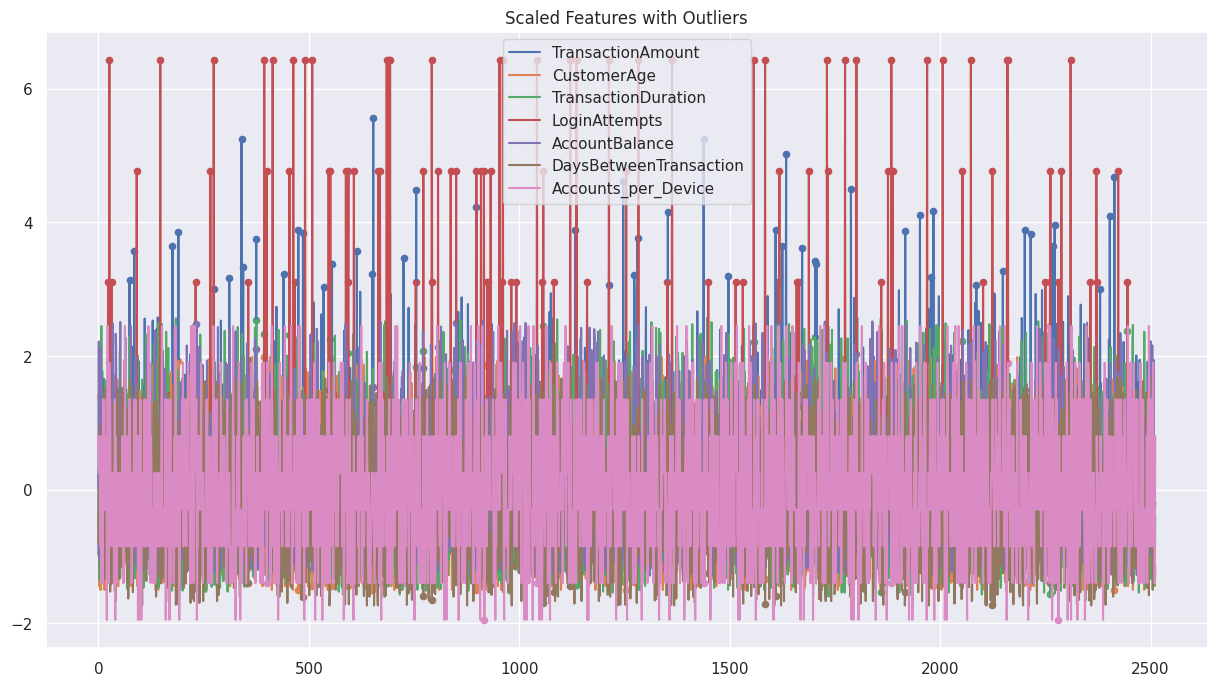

In [33]:

scaled = StandardScaler().fit_transform(features)

plt.figure(figsize=(15,8))

for i, col in enumerate(features.columns):
    plt.plot(scaled[:, i], label=col)

    plt.scatter(
        np.where(outlier_rows)[0],
        scaled[outlier_rows, i],
        s=20
    )

plt.legend()
plt.title("Scaled Features with Outliers")
plt.grid(True)
plt.show()

In [34]:
K=3
N_INIT=10

In [35]:
# remove the outliers from the features
no_outlier_features = features[~outlier_rows]

print("Original shape:", features.shape)
print("After removing outliers:", no_outlier_features.shape)

Original shape: (2512, 7)
After removing outliers: (2372, 7)


In [36]:
"""
Scale all important nomerical columns
"""
scaler = StandardScaler()
scaled_features = scaler.fit_transform(no_outlier_features)

In [37]:
kmeansPLUS_final = KMeans(n_clusters=K, init='k-means++',
                          n_init=N_INIT, max_iter=300,
                          tol=0.0001, verbose=0,
                          random_state=42).fit(scaled_features)

print(f'The final SSE with scaled is using k-means++: {kmeansPLUS_final.inertia_} ')

# get the k-means labels
kmeansPLUS_final_features_lables = kmeansPLUS_final.labels_
# get the centroid for each clusters
scaled_kmeansPLUS_final_centroids = kmeansPLUS_final.cluster_centers_
print(f'Labels after scaled using k-means++: {np.unique(kmeansPLUS_final_features_lables)}')

The final SSE with scaled is using k-means++: 11974.359478172511 
Labels after scaled using k-means++: [0 1 2]


PCA explained variance:  [0.19 0.15]


/tmp/ipykernel_2382/1725313027.py:41: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], ax=ax[0], hue=labels, palette=PAL)
/tmp/ipykernel_2382/1725313027.py:64: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.scatterplot(x=tsne_results[:,0], y=tsne_results[:,1], ax=ax[1], hue=labels, palette=PAL)


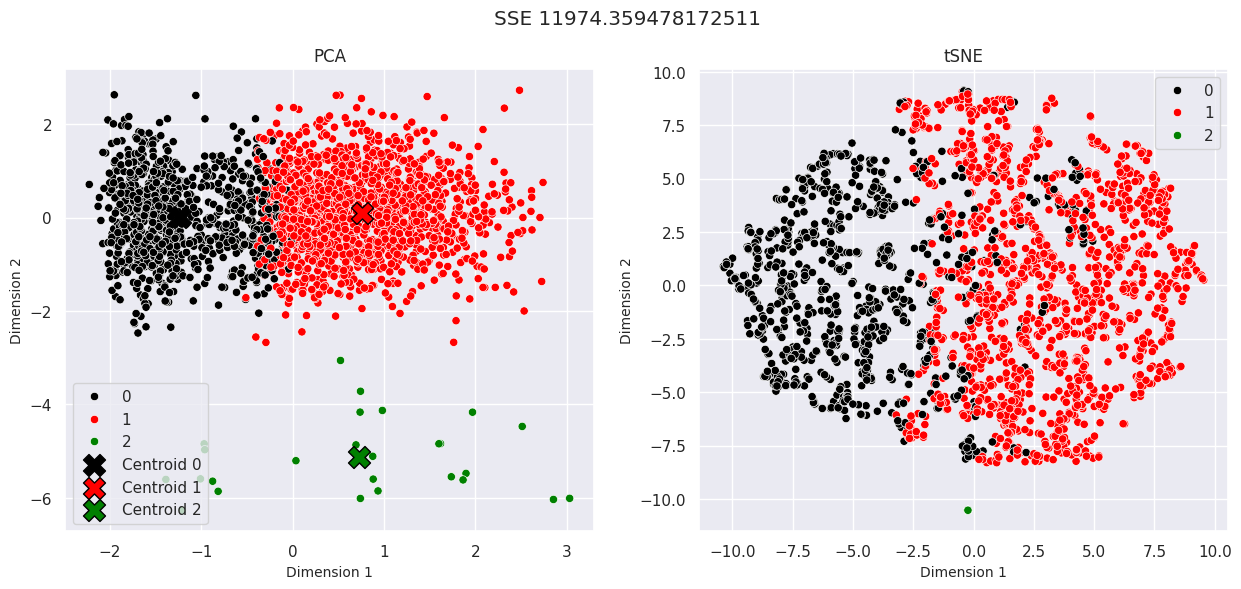

In [38]:
"""
Plot the PCA and tSNE of scaled features for k-means++
"""
PCA_tSNE_visualization(scaled_features,
                       DIMENSIONS,
                       kmeansPLUS_final_features_lables,
                       PAL, scaled_kmeansPLUS_final_centroids,
                       kmeansPLUS_final.inertia_)

This was the previous with outlier clustering

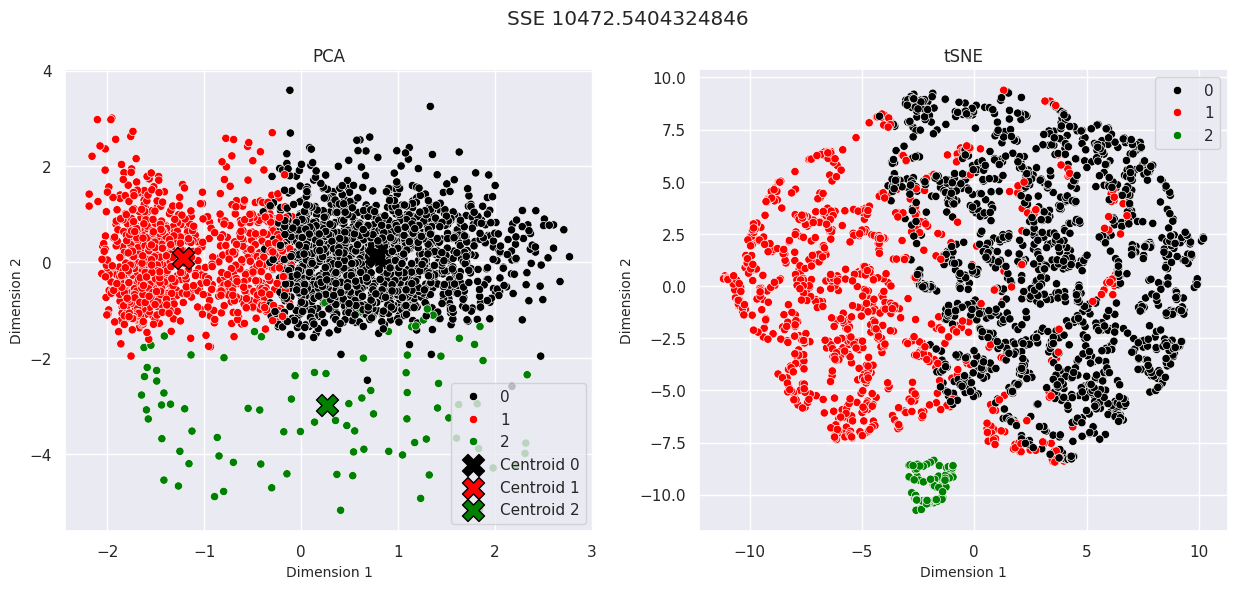